In [31]:
import pandas as pd
s=pd.read_csv("/content/da project", on_bad_lines='skip')
print(s)

      Age          Workclass Final Weight    Education  EducationNum  \
0      39          State-gov        77516    Bachelors            13   
1      50   Self-emp-not-inc        83311    Bachelors            13   
2      38            Private       215646      HS-grad             9   
3      53            Private       234721         11th             7   
4      28            Private       338409    Bachelors            13   
...    ..                ...          ...          ...           ...   
47344  27            Private       257302   Assoc-acdm            12   
47345  40            Private       154374      HS-grad             9   
47346  58            Private       151910      HS-grad             9   
47347  22            Private       201490      HS-grad             9   
47348  52       Self-emp-inc       287927      HS-grad             9   

            Marital Status          Occupation    Relationship    Race  \
0            Never-married        Adm-clerical   Not-in-famil

In [32]:
print(s.head(11))
print(s.tail(10))
print(s.shape)
print(s.info)
print(s.values)
print(len(s))
print(s.index)
print(s.count())
print(s.dtypes)

   Age          Workclass Final Weight      Education  EducationNum  \
0   39          State-gov        77516      Bachelors            13   
1   50   Self-emp-not-inc        83311      Bachelors            13   
2   38            Private       215646        HS-grad             9   
3   53            Private       234721           11th             7   
4   28            Private       338409      Bachelors            13   
5   37            Private       284582        Masters            14   
6   49            Private       160187            9th             5   
7   52   Self-emp-not-inc       209642        HS-grad             9   
8   31            Private        45781        Masters            14   
9   42            Private       159449      Bachelors            13   
10  37            Private       280464   Some-college            10   

            Marital Status          Occupation    Relationship    Race  \
0            Never-married        Adm-clerical   Not-in-family   White   

In [ ]:
'''
1.Find the average age and hours-per-week separately for each income category.
2.Find the total number of rows and columns in the df DataFrame.
3.Display the first 15 rows and only the columns age, education, and income.
4.Find all unique values present in the workclass column.
5.Count how many unique values are present in the occupation column.
6.Find the number of missing values in each column.
7.Find the average, median, minimum, and maximum hours-per-week using .agg().
8.Find the number of people in each education category using value_counts().
9.Calculate the percentage of each education category using NumPy.
10.Filter people whose age is between 25 and 40 and whose income is >50K.
11.Find the minimum, maximum, mean, and standard deviation of capital-gain and capital-loss using .agg().
12.Find the top 5 most common native-country values using value_counts().
13.Find the average hours-per-week for people whose education is Bachelors or Masters.
14.Group the data by education and calculate the count, mean age, and maximum age using .groupby() and .agg().
15.Create a summary showing each income category with its count, percentage, average age,
and average hours-per-week using Pandas, NumPy, groupby(), and .agg().
'''

In [ ]:
import numpy as np
#viewing and filtering
#1
print(s.groupby("Income").agg({"Age":['mean'],"Hours per Week":["mean"]}))
print("______________________________________________")
#2
print(s.shape)
print("______________________________________________")
#3
print(s[["Age","Education","Income"]].head(16))
print("______________________________________________")
#4
print(s["Workclass"].unique())
print("______________________________________________")
#5
print(s["Occupation"].nunique())
print("______________________________________________")
#6
print(s.isna().sum())
print("______________________________________________")
#7
print(s["Hours per Week"].agg(["mean","median","min","max"]))
print("______________________________________________")
#8
print(s["Education"].value_counts())
print("______________________________________________")
#9
print(s["Education"].value_counts(normalize=True) * 100)
print("______________________________________________")
#10
print(
    s[
        (s["Age"] >= 25) &
        (s["Age"] <= 40) &
        (s["Income"] == ">50K")
    ]
)
print("______________________________________________")
#11
print(s[["Capital Gain","capital loss"]].agg(["min","max","mean","std"]))
print("______________________________________________")
#12
print(s["Native Country"].value_counts().head(5))
print("______________________________________________")
#13
print(s[s["Education"].isin(["Bachelors", "Masters"])]['Hours per Week'].mean())
print("______________________________________________")
#14
print(s.groupby("Education").count())
print(s.groupby("Education").agg({"Age":["count","mean","max"]}))
print("______________________________________________")
#15
income_summary = s.groupby('Income').agg(
    Count=('Income', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Hours_Per_Week=('Hours per Week', 'mean'))
income_summary['Percentage (%)'] = (income_summary['Count'] / income_summary['Count'].sum()) * 100
income_summary = income_summary[['Count', 'Percentage (%)', 'Average_Age', 'Average_Hours_Per_Week']]
print(income_summary)

              Age Hours per Week
             mean           mean
Income                          
<=50K   36.783738      38.840210
>50K    44.249841      45.473026
______________________________________________
(32561, 15)
______________________________________________
    Age      Education  Income
0    39      Bachelors   <=50K
1    50      Bachelors   <=50K
2    38        HS-grad   <=50K
3    53           11th   <=50K
4    28      Bachelors   <=50K
5    37        Masters   <=50K
6    49            9th   <=50K
7    52        HS-grad    >50K
8    31        Masters    >50K
9    42      Bachelors    >50K
10   37   Some-college    >50K
11   30      Bachelors    >50K
12   23      Bachelors   <=50K
13   32     Assoc-acdm   <=50K
14   40      Assoc-voc    >50K
15   34        7th-8th   <=50K
______________________________________________
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
____________________________

In [ ]:
"""
statistical analysis
1.Select and display only the age column from the dataset.
2.Select the age, education, occupation, and income columns.
3.Display the first 10 rows using iloc.
4.Select rows 10 to 20 and display only the age and education columns.
5.Filter and display all people whose age is greater than 50.
6.Filter and display all people whose income is >50K.
7.Filter people whose age is greater than 40 and
hours-per-week is greater than 40.
8.Filter people whose education is either Bachelors
 or Masters using isin().
9.Find the mean, median, minimum, and maximum age of
 people in the dataset.
10.Find the standard deviation of age and hours-per-week.
11.Use describe() to generate the statistical summary
 of all numericalcolumns.
12.Find the number of unique values in the education column and display
 their
frequency using value_counts().
13.Find the number of people in each income category using value_counts().
15.Find the average hours-per-week of people whose income is >50K.
16.Find the average age of people whose education is Bachelors.
17.Find the youngest and oldest person in the dataset.
18.Calculate the correlation between the numerical columns using corr().
19.Find the most common value (mode) of the education and occupation columns."""

In [ ]:
#statistical analysis
#1
print(s["Age"])
print("______________________________________________")
#2
print(s[["Age","Education","Occupation","Income"]])
print("______________________________________________")
#3
print(s.iloc[0:11])
print("______________________________________________")
#4
print(s[["Age","Education"]].iloc[10:21])
print("______________________________________________")
#5
print(s[s["Age"]>50])
print("______________________________________________")
#6
print(s[s["Income"]>"50k"])
print("______________________________________________")
#7
print(s[
    (s["Age"]>40) &
    (s["Hours per Week"]>40)
])
print("______________________________________________")
#8
print(s[
    s["Education"].isin([" Bachelors","Masters"])
])
print("______________________________________________")
#9
print(s["Age"].agg(["mean","median","min","max"]))
print("______________________________________________")
#10
print(s[["Age","Hours per Week"]].agg(["std"]))
print("______________________________________________")
#11
print(s.describe)
print("______________________________________________")
#12
print(s["Education"].nunique())
print(s["Education"].value_counts())
print("______________________________________________")
#13
print(s["Income"].value_counts())
print("______________________________________________")
#15
print(s[s["Income"]==">50k"]["Hours per Week"].mean())
print("______________________________________________")
#16
print(s[s["Education"]==" Bachelors"]["Age"].mean())
print("______________________________________________")
#17
print(s["Age"].agg(["min","max"]))
print("______________________________________________")
#18
print(s.corr(numeric_only=True))
print("______________________________________________")
# 19.
print(s[['Age', 'Hours per Week']].corr())
print("______________________________________________")
# 20.
print(
    "Education Mode:",
    s['Education'].mode()[0]
)

print(
    "Occupation Mode:",
    s['Occupation'].mode()[0]
)

0        39
1        50
2        38
3        53
4        28
         ..
32556    27
32557    40
32558    58
32559    22
32560    52
Name: Age, Length: 32561, dtype: int64
______________________________________________
       Age    Education          Occupation  Income
0       39    Bachelors        Adm-clerical   <=50K
1       50    Bachelors     Exec-managerial   <=50K
2       38      HS-grad   Handlers-cleaners   <=50K
3       53         11th   Handlers-cleaners   <=50K
4       28    Bachelors      Prof-specialty   <=50K
...    ...          ...                 ...     ...
32556   27   Assoc-acdm        Tech-support   <=50K
32557   40      HS-grad   Machine-op-inspct    >50K
32558   58      HS-grad        Adm-clerical   <=50K
32559   22      HS-grad        Adm-clerical   <=50K
32560   52      HS-grad     Exec-managerial    >50K

[32561 rows x 4 columns]
______________________________________________
    Age          Workclass  ...  Native Country  Income
0    39          State-gov  .

In [ ]:
'''
# Cleaning
1.Identify the number of missing values present in each column of the Adult dataset.
2.Find the total number of NaN values present in the entire Adult dataset.
3.Replace all ? values in the Adult dataset with NaN using NumPy.
4.Fill missing values in the workclass column with the constant value "Unknown".
5.Fill missing values in the occupation column with the constant value "Not Available".
6.Find the mean of the age column and use it to fill its missing values.
7.Find the median of hours-per-week and use it to fill its missing values.
8.Find the mode of the workclass column and use it to fill its missing values.
9.Find the mode of the occupation column and use it to fill its missing values.
10.Delete all rows containing at least one missing value from the Adult dataset.
11.Delete rows where the occupation column contains a missing value.
12.Delete the native-country column from the Adult dataset.
13.Find the number of missing values in age, workclass, occupation, and native-country separately.
14.Fill missing values in age using mean and missing values in workclass using mode.
'''

In [63]:
#1
print(s.isna())
#2
print(s.isna().sum())
#3
s=s.replace(" ?",None)
#4
a=s.fillna({"Workclass":"Unknown"})
print(a)
#5
b=s.fillna({"Occupation":"Not Available"})
print(b)
#6
s['Age'] = s['Age'].fillna(s['Age'].mean())
print(s["Age"])
#7
s['Hours per Week']=s['Hours per Week'].fillna(s['Hours per Week'].median())
print(s["Hours per Week"])
#8
s["Workclass"]=s["Workclass"].fillna(s["Workclass"].mode())
print(s["Workclass"])
#9
s["Occupation"]=s["Occupation"].fillna(s["Occupation"].mode())
print(s["Occupation"])
#10
print(s.dropna())
print(s.dropna(inplace=True))
#11
print(s.dropna(subset=["Occupation"],inplace=True))
#12
print(s.drop("Native Country", axis=1, inplace=True, errors='ignore'))
13
print(s[["Age","Workclass","Occupation"]].isna().sum())
#14
print(s["Workclass"].fillna(s["Workclass"].mode()[0],inplace=True))
print(s["Age"].fillna(s["Age"].mean(),inplace=True))

         Age  Workclass  Final Weight  Education  EducationNum  \
0      False      False         False      False         False   
1      False      False         False      False         False   
2      False      False         False      False         False   
3      False      False         False      False         False   
4      False      False         False      False         False   
...      ...        ...           ...        ...           ...   
47344  False      False         False      False         False   
47345  False      False         False      False         False   
47346  False      False         False      False         False   
47347  False      False         False      False         False   
47348  False      False         False      False         False   

       Marital Status  Occupation  Relationship   Race  Gender  Capital Gain  \
0               False       False         False  False   False         False   
1               False       False         False

/tmp/ipykernel_3136/3840579755.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  print(s["Workclass"].fillna(s["Workclass"].mode()[0],inplace=True))
/tmp/ipykernel_3136/3840579755.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [61]:
print(s.drop("Native Country", axis=1, inplace=True, errors='ignore'))


None


In [38]:
#Detecting Outliers
Q1=s["Hours per Week"].quantile(0.25)
Q3=s['Hours per Week'].quantile(0.75)
IQR=Q3-Q1
lower_bound=(Q1-1.5*IQR)
upper_bound=Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

32.5
52.5


In [64]:
from scipy.stats import zscore
s["Age_zscore"]=zscore(s["Age"])
print(s["Age_zscore"])
z_outliers=s[s["Age_zscore"].abs()>3]
print("Z-Score Outliers:",len(z_outliers))

0        0.042966
1        0.880253
2       -0.033151
3        1.108604
4       -0.794321
           ...   
47344   -0.870438
47345    0.119083
47346    1.489189
47347   -1.251023
47348    1.032487
Name: Age_zscore, Length: 43855, dtype: float64
Z-Score Outliers: 172


In [65]:
# Winsorization
from scipy.stats.mstats import winsorize
s["Age_winsorized"]=winsorize(s["Age"],limits=[0,0.5])
print(s.head())


   Age          Workclass Final Weight   Education  EducationNum  \
0   37          State-gov        77516   Bachelors            13   
1   37   Self-emp-not-inc        83311   Bachelors            13   
2   37            Private       215646     HS-grad             9   
3   37            Private       234721        11th             7   
4   28            Private       338409   Bachelors            13   

        Marital Status          Occupation    Relationship    Race   Gender  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   Capital Gain  capital loss  Hours per Week  Income  Age_zscore  \
0        2174.0           0.0            40.0  

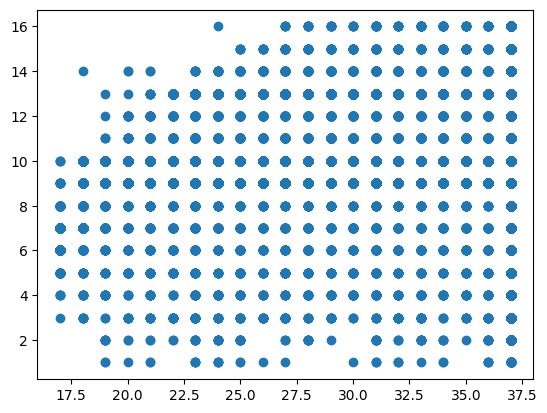

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(data=s, x="Age", y="EducationNum")

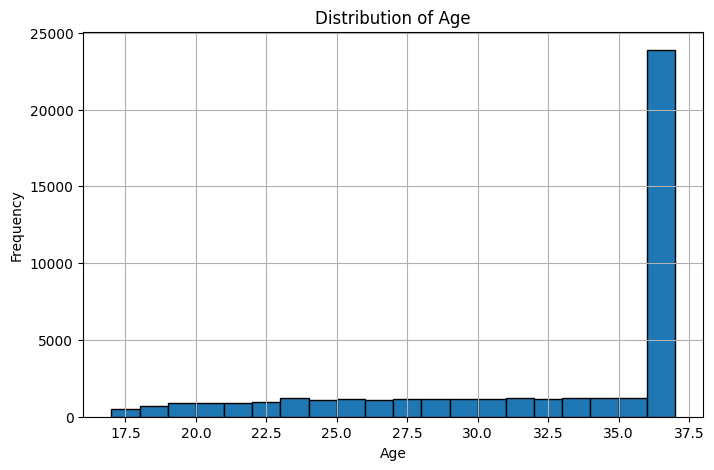

In [71]:
import matplotlib.pyplot as plt
s['Age'].hist(bins=20, edgecolor='black', figsize=(8,5))
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [74]:
import plotly.express as px
education = s["Education"].value_counts().head(10)
fig = px.pie(
    values=education.values,
    names=education.index,
    title="Education Distribution"
)

fig.show()

In [ ]:
!pip uninstall -y autoviz

Found existing installation: autoviz 0.1.905
Uninstalling autoviz-0.1.905:
  Successfully uninstalled autoviz-0.1.905


In [ ]:
import pandas as pd
from autoviz.AutoViz_Class import AutoViz_Class
AV=AutoViz_Class()
data=pd.read_csv("da project")
AV.AutoViz(
    filename="da project.csv",
    sep=",",
    depVar="Income",
    dfte=data
)

Shape of your Data Set loaded: (32561, 15)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  6
    Number of String-Categorical Columns =  7
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  1
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    14 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Binary_Classification problem #####################
To fix these data qual

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Age,int64,0.000000,0,17.000000,90.000000,Column has 142 outliers greater than upper bound (78.00) or lower than lower bound(-2.00). Cap them or remove them.
Workclass,object,0.000000,0,,,"2 rare categories: [' Without-pay', ' Never-worked']. Group them into a single category or drop the categories."
Final Weight,int64,0.000000,66,12285.000000,1484705.000000,Column has 993 outliers greater than upper bound (415742.00) or lower than lower bound(-60922.00). Cap them or remove them.
Education,object,0.000000,0,,,"2 rare categories: [' 1st-4th', ' Preschool']. Group them into a single category or drop the categories."
EducationNum,int64,0.000000,0,1.000000,16.000000,Column has 1193 outliers greater than upper bound (16.50) or lower than lower bound(4.50). Cap them or remove them.
Marital Status,object,0.000000,0,,,1 rare categories: [' Married-AF-spouse']. Group them into a single category or drop the categories.
Occupation,object,0.000000,0,,,"2 rare categories: [' Priv-house-serv', ' Armed-Forces']. Group them into a single category or drop the categories."
Relationship,object,0.000000,0,,,No issue
Race,object,0.000000,0,,,"2 rare categories: [' Amer-Indian-Eskimo', ' Other']. Group them into a single category or drop the categories."
Gender,object,0.000000,0,,,No issue


Total Number of Scatter Plots = 21
All Plots done
Time to run AutoViz = 11 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [ ]:
!pip uninstall  -y sweetviz

Found existing installation: sweetviz 2.3.3
Uninstalling sweetviz-2.3.3:
  Successfully uninstalled sweetviz-2.3.3


In [ ]:
import pandas as pd
import sweetviz as sv
data=pd.read_csv("da project")
report=sv.analyze(data)
report.show_html("sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
!pip uninstall -y dtale


Found existing installation: dtale 3.22.0
Uninstalling dtale-3.22.0:
  Successfully uninstalled dtale-3.22.0


In [ ]:
import pandas as pd
import dtale
data=pd.read_csv("da project")
dtale.show(data)

http://22220bae65a9:40000/dtale/main/1

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport
data=pd.read_csv("da project")
profile=ProfileReport(data,title="Adult Dataset Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:02<00:00,  5.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]